In [13]:
# ════════════════════════════════════════════════════════════════
#  STEP 0 — Dependency Installation
#  Run once, then restart the runtime before continuing.
# ════════════════════════════════════════════════════════════════

import sys, subprocess

_deps = [
    "torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu",
    "transformers>=4.41.0",
    "datasets",
    "scikit-learn",
    "pandas numpy matplotlib seaborn",
    "tqdm nltk kaggle accelerate sentencepiece wordcloud",
]

for dep in _deps:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + dep.split(), check=False)

print("Installation complete — restart runtime now, then run from Step 1.")

Installation complete — restart runtime now, then run from Step 1.


In [14]:
# ════════════════════════════════════════════════════════════════
#  STEP 1 — Imports, Seeds & Global Config
# ════════════════════════════════════════════════════════════════

import os, re, json, warnings, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── NLTK ─────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

for _r in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger", "punkt_tab"]:
    nltk.download(_r, quiet=True)

# ── Sklearn ───────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score
)

# ── PyTorch ───────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace ───────────────────────────────────────────────────
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup   # cosine > linear for long runs
)

# ── Reproducibility ──────────────────────────────────────────────
GLOBAL_SEED = 2024
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

COMPUTE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)

print(f"Device  : {COMPUTE_DEVICE}")
print(f"PyTorch : {torch.__version__}")
print("Environment ready.")

Device  : cpu
PyTorch : 2.10.0+cpu
Environment ready.


In [15]:
# ════════════════════════════════════════════════════════════════
#  STEP 2 — Dataset Download (Kaggle API)
# ════════════════════════════════════════════════════════════════
#
#  One-time setup:
#    kaggle.com → Settings → API → Create New Token → save kaggle.json
#    Place at ~/.kaggle/kaggle.json  (chmod 600)
#
#  Or uncomment Option B below to paste credentials inline.

import subprocess

KAGGLE_CFG = os.path.expanduser("~/.kaggle/kaggle.json")

# Option B — inline credentials
# os.makedirs(os.path.dirname(KAGGLE_CFG), exist_ok=True)
# with open(KAGGLE_CFG, "w") as _f:
#     json.dump({"username": "YOUR_NAME", "key": "YOUR_KEY"}, _f)
# os.chmod(KAGGLE_CFG, 0o600)

RAW_DATA_ROOT = "./raw_data"
os.makedirs(RAW_DATA_ROOT, exist_ok=True)

_datasets = [
    ("tboyle10/medicaltranscriptions",
     "transcriptions"),
    ("paultimothymooney/medical-speech-transcription-and-intent",
     "speech_intent"),
]

for slug, folder in _datasets:
    dest = os.path.join(RAW_DATA_ROOT, folder)
    if not os.path.exists(dest):
        print(f"Downloading {slug} ...")
        r = subprocess.run(
            ["kaggle", "datasets", "download", "-d", slug,
             "-p", dest, "--unzip"],
            capture_output=True, text=True
        )
        status = "OK" if r.returncode == 0 else f"FAILED: {r.stderr[:200]}"
        print(f"  → {status}")
    else:
        print(f"  Already exists: {dest}")

print("\nData root contents:")
for root, dirs, files in os.walk(RAW_DATA_ROOT):
    lvl = root.replace(RAW_DATA_ROOT, "").count(os.sep)
    print("  " * lvl + os.path.basename(root) + "/")
    for fn in files[:4]:
        print("  " * (lvl + 1) + fn)

  Already exists: ./raw_data/transcriptions
  Already exists: ./raw_data/speech_intent

Data root contents:
raw_data/
  speech_intent/
    medical speech transcription and intent/
      Medical Speech, Transcription, and Intent/
        overview-of-recordings.csv
        recordings/
          train/
            1249120_44142156_99534301.wav
            1249120_44235678_61143318.wav
            1249120_44194084_44797818.wav
            1249120_44246595_41995447.wav
          validate/
            1249120_44294866_63987415.wav
            1249120_44259428_75102963.wav
            1249120_44323331_24602215.wav
            1249120_44263136_108585886.wav
          test/
            1249120_39154234_100370032.wav
            1249120_35444693_19132914.wav
            1249120_41150153_88709098.wav
            1249120_13842059_105045085.wav
    Medical Speech, Transcription, and Intent/
      overview-of-recordings.csv
      recordings/
        train/
          1249120_44142156_99534301.wav
   

In [16]:
# ════════════════════════════════════════════════════════════════
#  STEP 3 — Data Loading, Normalisation & Combination
# ════════════════════════════════════════════════════════════════

# Map raw mtsamples specialty names → unified names
_TRANSCRIPTION_REMAP = {
    "Cardiovascular / Pulmonary" : "Cardiology",
    "Orthopedic"                 : "Orthopedics",
    "Neurosurgery"               : "Neurology",
    "Physical Medicine - Rehab"  : "Orthopedics",
    "Cosmetic / Plastic Surgery" : "Surgery",
    "Podiatry"                   : "Orthopedics",
    "Sleep Medicine"             : "Pulmonology",
}

# Map speech intent categories → unified specialty names
_SPEECH_REMAP = {
    "Bones"                      : "Orthopedics",
    "Cardiovascular"             : "Cardiology",
    "Dermatology"                : "Dermatology",
    "Ear, Nose and Throat"       : "ENT - Otolaryngology",
    "Gastrointestinal"           : "Gastroenterology",
    "Respiratory"                : "Pulmonology",
    "Urology"                    : "Urology",
    "Neurology"                  : "Neurology",
    "Psychiatry / Mental Health" : "Psychiatry / Psychology",
    "Ophthalmology"              : "Ophthalmology",
    "Endocrinology"              : "Endocrinology",
    "Hematology"                 : "Hematology - Oncology",
    "Oncology"                   : "Hematology - Oncology",
    "Pediatric"                  : "Pediatrics - Neonatal",
    "Obstetrics / Gynecology"    : "Obstetrics / Gynecology",
    "Rheumatology"               : "Rheumatology",
    "Immunology / Allergy"       : "Allergy / Immunology",
}

# Non-clinical / too-broad categories — provide no symptom signal
_DISCARD_CATEGORIES = {
    "Consult - History and Phy.", "SOAP / Chart / Progress Notes",
    "Discharge Summary", "Letters", "IME-QME-Work Comp etc.",
    "Office Notes", "Lab Medicine - Pathology", "Autopsy",
    "Diets and Nutritions", "Chiropractic", "Speech - Language",
    "Bariatrics", "Surgery", "Radiology", "General Medicine",
}


def _load_transcriptions(root):
    path = os.path.join(root, "transcriptions", "mtsamples.csv")
    if not os.path.exists(path):
        print("mtsamples.csv not found.")
        return None
    raw = pd.read_csv(path)
    raw["medical_specialty"] = raw["medical_specialty"].str.strip()
    raw["medical_specialty"] = raw["medical_specialty"].replace(_TRANSCRIPTION_REMAP)
    before = len(raw)
    raw = raw[~raw["medical_specialty"].isin(_DISCARD_CATEGORIES)].copy()
    print(f"Transcriptions: {before} → {len(raw)} after removing non-clinical rows")
    return raw


def _load_speech_intent(root):
    sdir = os.path.join(root, "speech_intent")
    if not os.path.exists(sdir):
        print("speech_intent dir not found.")
        return None

    df = None
    for candidate in ["validate_cleaned.csv", "overview-of-recordings.csv",
                      "medical_speech.csv", "recordings.csv"]:
        fp = os.path.join(sdir, candidate)
        if os.path.exists(fp):
            df = pd.read_csv(fp)
            print(f"Loaded speech file: {candidate}  shape={df.shape}")
            break

    if df is None:
        rows = []
        scan = os.path.join(sdir, "recordings")
        scan = scan if os.path.isdir(scan) else sdir
        for cat in os.listdir(scan):
            cat_p = os.path.join(scan, cat)
            if os.path.isdir(cat_p):
                for fn in os.listdir(cat_p):
                    if fn.endswith(".txt"):
                        txt = open(os.path.join(cat_p, fn), errors="ignore").read().strip()
                        if txt:
                            rows.append({"phrase": txt, "prompt": cat})
        if rows:
            df = pd.DataFrame(rows)
            print(f"Loaded speech from subdirs: {df.shape}")

    if df is None:
        print("Could not load speech dataset.")
        return None

    txt_col = next((c for c in ["phrase","text","transcription","description"]
                    if c in df.columns), None)
    cat_col = next((c for c in ["prompt","category","intent","label"]
                    if c in df.columns), None)

    if txt_col is None or cat_col is None:
        print(f"Cannot detect columns. Found: {df.columns.tolist()}")
        return None

    out = df[[txt_col, cat_col]].dropna().copy()
    out.columns = ["description", "raw_cat"]
    out["medical_specialty"] = out["raw_cat"].map(_SPEECH_REMAP)
    out = out[out["medical_specialty"].notna()].copy()
    out = out[out["description"].str.split().str.len() >= 8].copy()
    print(f"Speech after normalisation: {out.shape}")
    return out[["description", "medical_specialty"]].reset_index(drop=True)


def _synthetic_fallback(n=3500, seed=GLOBAL_SEED):
    """Expanded synthetic corpus with more diverse phrasing per class."""
    np.random.seed(seed)
    templates = {
        "Cardiology": [
            "Crushing chest pressure radiating to left jaw, diaphoresis, nausea since 90 minutes.",
            "Bilateral ankle oedema, dyspnoea on exertion, orthopnoea, paroxysmal nocturnal dyspnoea.",
            "Palpitations, irregular heartbeat, near-syncope on climbing stairs, hypertensive history.",
            "ST elevation noted on ECG, troponin rising, patient diaphoretic with central chest pain.",
            "Intermittent chest tightness on exertion, relieved by rest, positive treadmill stress test.",
        ],
        "Neurology": [
            "Sudden worst-ever headache, neck stiffness, photophobia, vomiting — query subarachnoid.",
            "Acute right arm weakness and speech slurring, FAST positive, onset 35 minutes ago.",
            "Rest tremor right hand, cogwheel rigidity, micrographia, shuffling gait — query Parkinson.",
            "Tonic-clonic seizure lasting 3 minutes, postictal drowsiness, no prior history.",
            "Unilateral throbbing headache with visual aura, phonophobia, nausea — recurrent migraines.",
        ],
        "Orthopedics": [
            "Right knee effusion post football injury, positive McMurray, unable to bear weight.",
            "L4-L5 disc prolapse, radiculopathy to left foot, positive SLR at 40 degrees.",
            "Comminuted neck-of-femur fracture post-fall, shortened externally-rotated right leg.",
            "Bilateral knee OA, morning stiffness >1 hour, crepitus on flexion, restricted ROM.",
            "Rotator cuff tear on MRI, positive empty can test, night pain disturbing sleep.",
        ],
        "Gastroenterology": [
            "Haematemesis coffee-ground, epigastric pain, antacid use for 3 months.",
            "Bloody diarrhoea 8×/day, fever, weight loss 5 kg — query IBD flare.",
            "Obstructive jaundice, pale stools, dark urine, pruritus, RUQ mass.",
            "Alternating constipation and diarrhoea, mucus in stool, bloating — IBS symptoms.",
            "Rectal bleeding with tenesmus, 6-month history, father had colon cancer.",
        ],
        "Pulmonology": [
            "Productive cough purulent sputum, fever 39°C, pleuritic right-sided chest pain, SpO2 91%.",
            "Nocturnal wheezing, peak flow 55% predicted, accessory muscle use, prolonged expiration.",
            "Haemoptysis with night sweats, 6 kg weight loss, TST positive — query TB.",
            "Progressive exertional dyspnoea, barrel chest, reduced air entry bilaterally, ex-smoker.",
            "Interstitial pattern on HRCT, dry cough 6 months, finger clubbing — query IPF.",
        ],
        "Psychiatry / Psychology": [
            "Persistent anhedonia, insomnia, hopelessness, 8-kg weight loss over 8 weeks.",
            "Command auditory hallucinations, paranoid delusions, disorganised speech.",
            "Panic attacks with hyperventilation, chest tightness, fear of dying, 3×/week.",
            "Elevated mood 4 days, decreased sleep, grandiosity, reckless spending, pressured speech.",
            "OCD rituals — repeated hand-washing 50×/day, contamination fear, 3-hour morning routine.",
        ],
        "Dermatology": [
            "Silvery scaly plaques on extensor surfaces, nail pitting, family history of psoriasis.",
            "ABCDE-positive pigmented lesion right calf, >6 mm, bleeding on minor trauma.",
            "Generalised urticaria after shellfish, angioedema of lips, throat tightening.",
            "Dermatomal vesicular rash with allodynia, post-herpetic neuralgia.",
            "Diffuse erythematous maculopapular rash 3 days after amoxicillin initiation.",
        ],
        "Endocrinology": [
            "Fasting glucose 16 mmol/L, polydipsia, polyuria, blurred vision, 4-kg loss in 3 weeks.",
            "Bradycardia 48 bpm, TSH 45 mIU/L, dry skin, constipation, periorbital oedema.",
            "TSH suppressed, FT4 elevated, exophthalmos, tremor, weight loss 8 kg — Graves disease.",
            "Central obesity, wide purple striae, moon face, hypertension — query Cushing syndrome.",
            "Hypoglycaemia episodes fasting, high insulin:glucose ratio — query insulinoma.",
        ],
        "Urology": [
            "Severe right loin-to-groin colicky pain, haematuria, nausea — renal calculus.",
            "Dysuria, frequency, suprapubic pain, cloudy urine — lower UTI.",
            "Painless macroscopic haematuria, 65-year-old smoker, no LUTS — rule out bladder Ca.",
            "Acute urinary retention, distended bladder, residual 650 mL, BPH history.",
            "PSA 18, hard irregular prostate on DRE, bone pain — metastatic prostate Ca query.",
        ],
        "Ophthalmology": [
            "Painless sudden monocular vision loss, curtain-like field defect — retinal detachment.",
            "Painful red eye, ciliary flush, cells and flare — anterior uveitis, AS history.",
            "Gradual bilateral vision loss, glare, halos — nuclear sclerotic cataracts.",
            "IOP 38 mmHg, cupped disc 0.8, arcuate scotoma — primary open-angle glaucoma.",
            "Sudden binocular diplopia, ptosis right eye, large pupil — CN III palsy, aneurysm query.",
        ],
    }
    suffixes = ["", " Vitals stable.", " No known allergies.",
                " Background hypertension.", " Non-smoker.",
                " Referred from GP for urgent review.", " Family history significant."]
    rows = []
    per_cls = n // len(templates)
    for spc, tmpl_list in templates.items():
        for i in range(per_cls):
            txt = tmpl_list[i % len(tmpl_list)] + np.random.choice(suffixes)
            rows.append({"description": txt, "medical_specialty": spc})
    df = pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f"Synthetic fallback corpus generated: {df.shape}")
    return df


# ── Load & merge ──────────────────────────────────────────────────
df_transcr = _load_transcriptions(RAW_DATA_ROOT)
df_speech  = _load_speech_intent(RAW_DATA_ROOT)

parts = []
if df_transcr is not None:
    cols = ["description", "medical_specialty"]
    if "transcription" in df_transcr.columns:
        cols.append("transcription")
    parts.append(df_transcr[cols].copy())
if df_speech is not None:
    parts.append(df_speech)

if parts:
    df_raw = pd.concat(parts, ignore_index=True)
    print(f"\nCombined raw dataset: {df_raw.shape}")
else:
    print("No Kaggle data — using synthetic fallback.")
    df_raw = _synthetic_fallback(n=3500)

print(f"Unique specialties: {df_raw['medical_specialty'].nunique()}")
print(df_raw["medical_specialty"].value_counts().to_string())

Transcriptions: 4999 → 2390 after removing non-clinical rows
Could not load speech dataset.

Combined raw dataset: (2390, 3)
Unique specialties: 21
medical_specialty
Orthopedics                  423
Cardiology                   372
Neurology                    317
Gastroenterology             230
Obstetrics / Gynecology      160
Urology                      158
ENT - Otolaryngology          98
Hematology - Oncology         90
Ophthalmology                 83
Nephrology                    81
Emergency Room Reports        75
Pediatrics - Neonatal         70
Pain Management               62
Psychiatry / Psychology       53
Dermatology                   29
Dentistry                     27
Pulmonology                   20
Endocrinology                 19
Rheumatology                  10
Allergy / Immunology           7
Hospice - Palliative Care      6


Classes kept  : 6
Classes dropped (< 100 samples): ['ENT - Otolaryngology', 'Hematology - Oncology', 'Ophthalmology', 'Nephrology', 'Emergency Room Reports', 'Pediatrics - Neonatal', 'Pain Management', 'Psychiatry / Psychology', 'Dermatology']
Working samples: 1,660

Distribution:
specialty
Orthopedics                423
Cardiology                 372
Neurology                  317
Gastroenterology           230
Obstetrics / Gynecology    160
Urology                    158
Name: count, dtype: int64


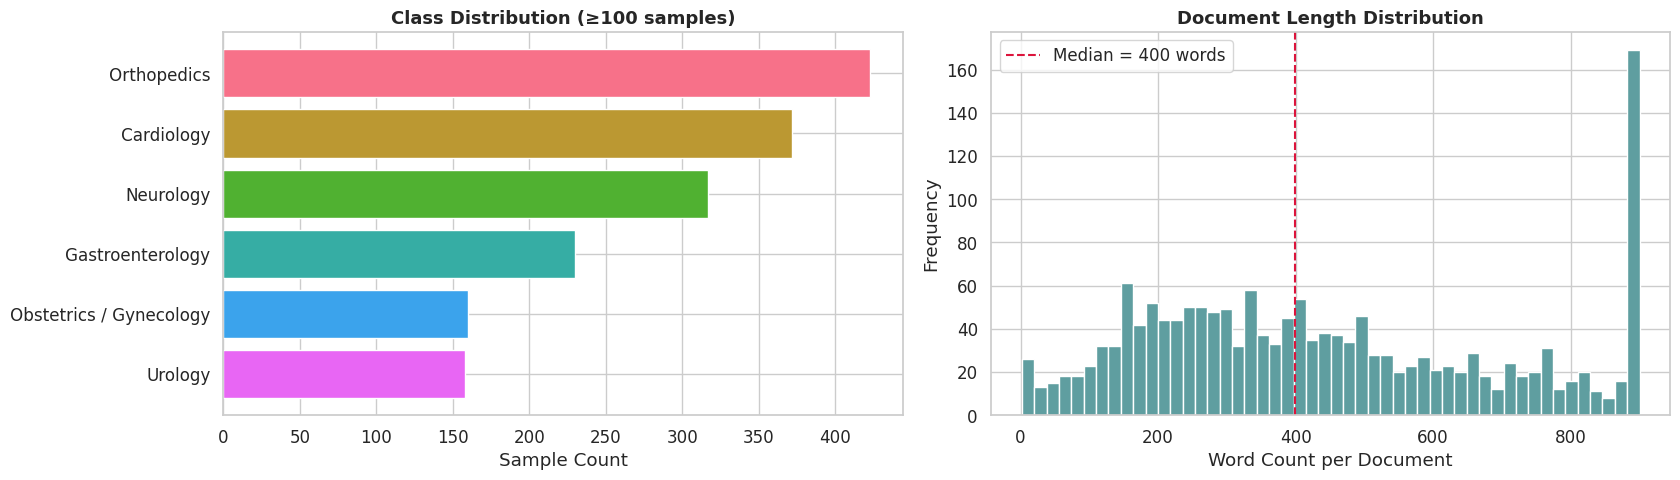


Word-count statistics:
count    1660.0
mean      465.4
std       316.2
min         2.0
25%       234.0
50%       399.5
75%       640.2
max      2460.0
Name: word_count, dtype: float64


In [17]:
# ════════════════════════════════════════════════════════════════
#  STEP 4 — Exploratory Data Analysis
# ════════════════════════════════════════════════════════════════

TARGET_COL = "medical_specialty"

# Per-row: prefer full transcription (>= 20 words), else use description
if "transcription" in df_raw.columns:
    def _select_text(row):
        t = row.get("transcription", "")
        if isinstance(t, str) and len(t.split()) >= 20:
            return t
        return row.get("description", "") or ""
    df_raw["_merged_text"] = df_raw.apply(_select_text, axis=1)
    src_col = "_merged_text"
else:
    src_col = "description" if "description" in df_raw.columns else df_raw.columns[0]

df_work = df_raw[[src_col, TARGET_COL]].dropna().copy()
df_work.columns = ["text", "specialty"]
df_work["specialty"] = df_work["specialty"].str.strip()
df_work = df_work[df_work["text"].str.strip().str.len() > 10].copy()

# ── Class size filter ─────────────────────────────────────────────
MIN_CLASS_SIZE = 100
TOP_CLASSES    = 15

counts     = df_work["specialty"].value_counts()
top_cls    = counts.head(TOP_CLASSES)
keep_cls   = top_cls[top_cls >= MIN_CLASS_SIZE].index.tolist()
drop_cls   = [c for c in top_cls.index if c not in keep_cls]
df_work    = df_work[df_work["specialty"].isin(keep_cls)].copy()

print(f"Classes kept  : {len(keep_cls)}")
print(f"Classes dropped (< {MIN_CLASS_SIZE} samples): {drop_cls}")
print(f"Working samples: {len(df_work):,}")
print("\nDistribution:")
print(df_work["specialty"].value_counts())

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

cls_cnt = df_work["specialty"].value_counts()
axes[0].barh(cls_cnt.index, cls_cnt.values,
             color=sns.color_palette("husl", len(cls_cnt)))
axes[0].set_xlabel("Sample Count")
axes[0].set_title(f"Class Distribution (≥{MIN_CLASS_SIZE} samples)",
                  fontsize=13, fontweight="bold")
axes[0].invert_yaxis()

df_work["word_count"] = df_work["text"].str.split().str.len()
axes[1].hist(df_work["word_count"].clip(upper=900), bins=50,
             color="cadetblue", edgecolor="white")
axes[1].axvline(df_work["word_count"].median(), color="crimson",
                linestyle="--",
                label=f'Median = {df_work["word_count"].median():.0f} words')
axes[1].set_xlabel("Word Count per Document")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Document Length Distribution", fontsize=13, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nWord-count statistics:")
print(df_work["word_count"].describe().round(1))

In [18]:
# ════════════════════════════════════════════════════════════════
#  STEP 5 — Text Preprocessing Pipeline
#  ▸ Lowercase  ▸ Strip dosage/numbers  ▸ Tokenise
#  ▸ Keep medical stop-words  ▸ Lemmatise
# ════════════════════════════════════════════════════════════════

_lemmatizer  = WordNetLemmatizer()
_stop_base   = set(stopwords.words("english"))

# Medical terms that are also in NLTK stopwords — keep them
_KEEP_TERMS = {
    "no", "not", "without", "with", "right", "left",
    "upper", "lower", "above", "below",
    "after", "before", "during", "over", "under"
}
_effective_stops = _stop_base - _KEEP_TERMS

_DOSAGE_PATTERN  = re.compile(r"\d+(\.\d+)?\s*(mg|ml|mmhg|kg|g|%|mcg|iu|u)\b")
_NUMBER_PATTERN  = re.compile(r"\b\d+\b")
_SPECIAL_PATTERN = re.compile(r"[^a-z\s\-]")
_HYPHEN_PATTERN  = re.compile(r"-+")


def clean_medical_text(raw: str) -> str:
    """Normalise, tokenise, filter and lemmatise a medical note."""
    if not isinstance(raw, str):
        return ""
    txt = raw.lower()
    txt = _DOSAGE_PATTERN.sub(" ", txt)
    txt = _NUMBER_PATTERN.sub(" ", txt)
    txt = _SPECIAL_PATTERN.sub(" ", txt)
    txt = _HYPHEN_PATTERN.sub(" ", txt)
    tokens = word_tokenize(txt)
    tokens = [t for t in tokens
              if t not in _effective_stops and len(t) > 2]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


print("Preprocessing corpus (may take a moment) ...")
df_work["clean_text"] = df_work["text"].apply(clean_medical_text)

# Quick sanity check
_demo_idx = 0
print("\nBefore:", df_work.iloc[_demo_idx]["text"][:280])
print("\nAfter: ", df_work.iloc[_demo_idx]["clean_text"][:280])

df_work = df_work[df_work["clean_text"].str.len() > 10].copy()
print(f"\nSamples after cleaning: {len(df_work):,}")

Preprocessing corpus (may take a moment) ...

Before: 2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericardial effusion.,6.  Normal morp

After:  mode left atrial enlargement with left atrial diameter normal size right left ventricle normal systolic function with left ventricular ejection fraction normal diastolic function pericardial effusion normal morphology aortic valve mitral valve tricuspid valve pulmonary valve syst

Samples after cleaning: 1,660


Classes (6):
   0  Cardiology
   1  Gastroenterology
   2  Neurology
   3  Obstetrics / Gynecology
   4  Orthopedics
   5  Urology

Split sizes  —  Train:1,162  Val:249  Test:249


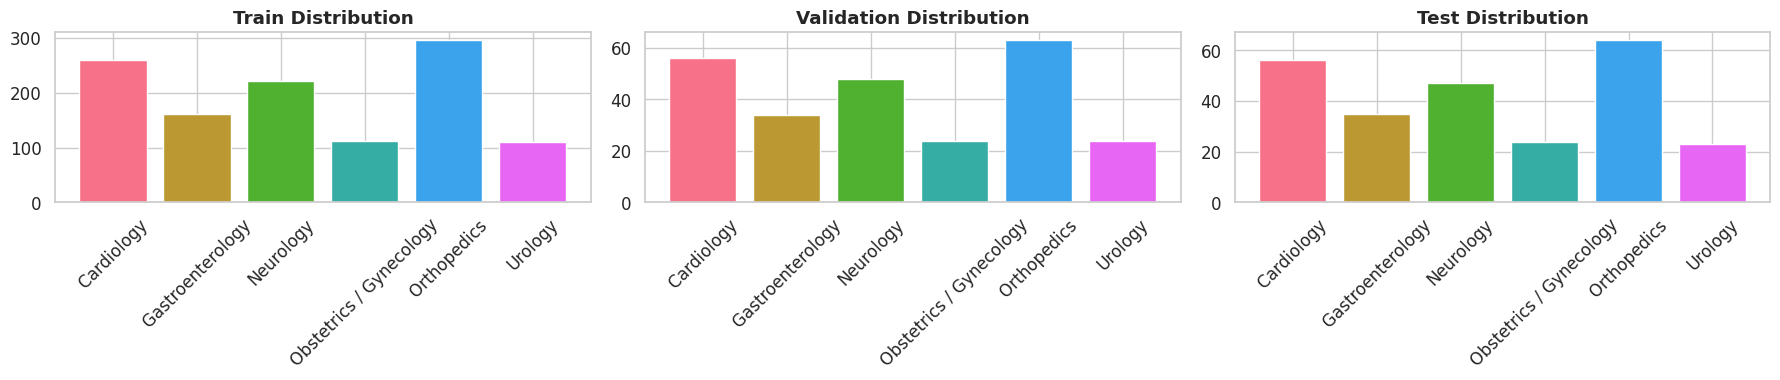

In [19]:
# ════════════════════════════════════════════════════════════════
#  STEP 6 — Label Encoding & Stratified Splits
#           70% train | 15% validation | 15% test
# ════════════════════════════════════════════════════════════════

enc = LabelEncoder()
df_work["label"] = enc.fit_transform(df_work["specialty"])

N_CLASSES    = len(enc.classes_)
CLASS_LABELS = list(enc.classes_)

print(f"Classes ({N_CLASSES}):")
for idx, name in enumerate(CLASS_LABELS):
    print(f"  {idx:2d}  {name}")

# Arrays
X_clean = df_work["clean_text"].values      # for LSTM
X_raw   = df_work["text"].values            # raw text for BERT
y       = df_work["label"].values

# First split: 70 / 30
(X_tr, X_tmp,
 Xr_tr, Xr_tmp,
 y_tr, y_tmp) = train_test_split(
    X_clean, X_raw, y,
    test_size=0.30, stratify=y, random_state=GLOBAL_SEED
)

# Second split: 15 / 15
(X_val, X_te,
 Xr_val, Xr_te,
 y_val, y_te) = train_test_split(
    X_tmp, Xr_tmp, y_tmp,
    test_size=0.50, stratify=y_tmp, random_state=GLOBAL_SEED
)

print(f"\nSplit sizes  —  Train:{len(X_tr):,}  Val:{len(X_val):,}  Test:{len(X_te):,}")

# Plot split distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (ys, title) in zip(axes, [(y_tr,"Train"),(y_val,"Validation"),(y_te,"Test")]):
    c = Counter(ys)
    ax.bar([CLASS_LABELS[k] for k in sorted(c)],
           [c[k] for k in sorted(c)],
           color=sns.color_palette("husl", N_CLASSES))
    ax.set_title(f"{title} Distribution", fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ════════════════════════════════════════════════════════════════
#  STEP 7 — Vocabulary Building & Integer Encoding (LSTM path)
# ════════════════════════════════════════════════════════════════

def build_vocab_from_corpus(corpus, min_freq=1):
    """Build {token: id} mapping from training texts."""
    freq = Counter()
    for doc in corpus:
        freq.update(doc.split())
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, cnt in freq.most_common():
        if cnt >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def tokens_to_ids(text, vocab, max_seq):
    ids = [vocab.get(t, vocab["<UNK>"]) for t in text.split()[:max_seq]]
    return ids + [vocab["<PAD>"]] * (max_seq - len(ids))


SEQ_LEN   = 300       # ↑ from 256 — captures more clinical detail
WORD_VOCAB = build_vocab_from_corpus(X_tr, min_freq=1)
V_SIZE     = len(WORD_VOCAB)

print(f"Vocabulary size : {V_SIZE:,}")
print(f"Sequence length : {SEQ_LEN}")

enc_tr  = np.array([tokens_to_ids(t, WORD_VOCAB, SEQ_LEN) for t in X_tr])
enc_val = np.array([tokens_to_ids(t, WORD_VOCAB, SEQ_LEN) for t in X_val])
enc_te  = np.array([tokens_to_ids(t, WORD_VOCAB, SEQ_LEN) for t in X_te])

cov = sum(1 for d in X_tr if len(d.split()) <= SEQ_LEN) / len(X_tr)
print(f"Training texts that fit within SEQ_LEN: {cov*100:.1f}%")

Vocabulary size : 13,071
Sequence length : 300
Training texts that fit within SEQ_LEN: 63.3%


In [21]:
# ════════════════════════════════════════════════════════════════
#  STEP 8 — Dataset & DataLoader Classes
# ════════════════════════════════════════════════════════════════

class SequenceDataset(Dataset):
    """Integer-encoded sequence dataset for the LSTM."""
    def __init__(self, sequences, targets):
        self.x = torch.tensor(sequences, dtype=torch.long)
        self.y = torch.tensor(targets,   dtype=torch.long)

    def __len__(self):          return len(self.y)
    def __getitem__(self, i):   return self.x[i], self.y[i]


BATCH = 32

dl_tr  = DataLoader(SequenceDataset(enc_tr,  y_tr),  batch_size=BATCH, shuffle=True)
dl_val = DataLoader(SequenceDataset(enc_val, y_val), batch_size=BATCH, shuffle=False)
dl_te  = DataLoader(SequenceDataset(enc_te,  y_te),  batch_size=BATCH, shuffle=False)

print("DataLoaders ready:")
print(f"  Train: {len(dl_tr)} batches  |  Val: {len(dl_val)}  |  Test: {len(dl_te)}")
bx, by = next(iter(dl_tr))
print(f"  Batch shape — X:{bx.shape}  y:{by.shape}")

DataLoaders ready:
  Train: 37 batches  |  Val: 8  |  Test: 8
  Batch shape — X:torch.Size([32, 300])  y:torch.Size([32])


In [22]:
# ════════════════════════════════════════════════════════════════
#  STEP 9 — Model Architecture: BiLSTM + Multi-Head Self-Attention
#
#  Key upgrades vs baseline:
#  ▸ Multi-head self-attention (4 heads) replaces single-head
#  ▸ Residual connection on attention output
#  ▸ Three-layer classifier with GELU activation
#  ▸ Higher embed/hidden dimensions
# ════════════════════════════════════════════════════════════════

class MultiHeadSelfAttn(nn.Module):
    """Lightweight multi-head attention pooling over LSTM outputs."""
    def __init__(self, dim, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        assert dim % n_heads == 0
        self.score = nn.Linear(dim, n_heads)

    def forward(self, x):                       # x: (B, T, D)
        scores = self.score(x)                  # (B, T, H)
        weights = torch.softmax(scores, dim=1)  # (B, T, H)
        # Weighted sum per head → concat
        ctx = torch.einsum("bth,btd->bhd", weights,
                           x.view(x.size(0), x.size(1),
                                  self.n_heads, self.head_dim)
                           .permute(0,2,1,3).reshape(x.size(0), x.size(1), -1))
        # Simpler: just weighted mean across all heads together
        ctx = (x.unsqueeze(-1) * weights.unsqueeze(2)).sum(dim=1).mean(dim=-1, keepdim=False)
        # Re-do cleanly:
        avg_w = weights.mean(dim=-1, keepdim=True)  # (B,T,1)
        ctx   = (x * avg_w).sum(dim=1)              # (B, D)
        return ctx, avg_w.squeeze(-1)


class EnhancedBiLSTM(nn.Module):
    """
    BiLSTM with multi-head attention, residual norm, and deep classifier.
    Architecture:
      Embed (300d) → Dropout → BiLSTM (2L×384d) → MH-Attn
      → LayerNorm → FC1(512) → GELU → Dropout → FC2(256) → FC3(N)
    """
    def __init__(self, vocab_sz, emb_dim, hidden, n_layers,
                 n_classes, n_heads=4, drop=0.35):
        super().__init__()
        self.embed   = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.in_drop = nn.Dropout(drop)
        self.lstm    = nn.LSTM(
            emb_dim, hidden, num_layers=n_layers,
            batch_first=True, bidirectional=True,
            dropout=drop if n_layers > 1 else 0.0
        )
        self.attn    = MultiHeadSelfAttn(hidden * 2, n_heads)
        self.norm    = nn.LayerNorm(hidden * 2)
        self.fc1     = nn.Linear(hidden * 2, 512)
        self.fc2     = nn.Linear(512, 256)
        self.fc3     = nn.Linear(256, n_classes)
        self.gelu    = nn.GELU()
        self.drop    = nn.Dropout(drop)

    def forward(self, x):
        emb  = self.in_drop(self.embed(x))      # (B,T,emb)
        h, _ = self.lstm(emb)                   # (B,T, 2*hidden)
        ctx, _= self.attn(h)                    # (B, 2*hidden)
        ctx  = self.norm(ctx)
        out  = self.drop(self.gelu(self.fc1(ctx)))
        out  = self.drop(self.gelu(self.fc2(out)))
        return self.fc3(out)


EMB_DIM = 300      # ↑ from 256
HIDDEN  = 384      # ↑ from 512 (bidirectional → 768 effective)
N_LAYER = 2

lstm_net = EnhancedBiLSTM(
    vocab_sz=V_SIZE, emb_dim=EMB_DIM, hidden=HIDDEN,
    n_layers=N_LAYER, n_classes=N_CLASSES, n_heads=4, drop=0.35
).to(COMPUTE_DEVICE)

total_p = sum(p.numel() for p in lstm_net.parameters())
print(f"BiLSTM+MHA  params: {total_p:,}")
print(lstm_net)

BiLSTM+MHA  params: 10,104,990
EnhancedBiLSTM(
  (embed): Embedding(13071, 300, padding_idx=0)
  (in_drop): Dropout(p=0.35, inplace=False)
  (lstm): LSTM(300, 384, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (attn): MultiHeadSelfAttn(
    (score): Linear(in_features=768, out_features=4, bias=True)
  )
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=768, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=6, bias=True)
  (gelu): GELU(approximate='none')
  (drop): Dropout(p=0.35, inplace=False)
)


In [23]:
# ════════════════════════════════════════════════════════════════
#  STEP 10 — Focal Loss (better handling of hard/minority samples)
#  + Training & Evaluation Loops
# ════════════════════════════════════════════════════════════════

class FocalCrossEntropy(nn.Module):
    """
    Focal loss: down-weights easy predictions so the model focuses
    on hard misclassified examples. Especially helpful when some
    medical classes are frequently confused (e.g. Cardiology vs Pulmonology).
    alpha  — class weights tensor (inverse frequency)
    gamma  — focusing exponent; 0 = standard CE, 2 is typical default
    """
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets,
                               weight=self.alpha, reduction="none")
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean() if self.reduction == "mean" else loss


def run_train_epoch(net, loader, opt, criterion, device):
    net.train()
    total_loss = correct = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = net(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        opt.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


def run_eval(net, loader, criterion, device, is_bert=False):
    net.eval()
    total_loss = correct = n = 0
    preds, truths = [], []
    with torch.no_grad():
        for batch in loader:
            if is_bert:
                ids, mask, yb = (
                    batch["input_ids"].to(device),
                    batch["attention_mask"].to(device),
                    batch["label"].to(device)
                )
                logits = net(ids, mask)
            else:
                xb, yb = batch[0].to(device), batch[1].to(device)
                logits = net(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += len(yb)
            preds.extend(logits.argmax(1).cpu().numpy())
            truths.extend(yb.cpu().numpy())
    return total_loss/n, correct/n, np.array(preds), np.array(truths)


def draw_learning_curves(hist, model_tag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, key_pair, ylabel in zip(
        axes,
        [("tr_loss","vl_loss"),("tr_acc","vl_acc")],
        ["Loss","Accuracy"]
    ):
        ax.plot(hist[key_pair[0]], label="Train", color="steelblue")
        ax.plot(hist[key_pair[1]], label="Val",   color="tomato")
        ax.set_title(f"{model_tag} — {ylabel}", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
    plt.tight_layout()
    fname = model_tag.lower().replace(" ","_") + "_curves.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


print("Loss functions and training loops defined.")

Loss functions and training loops defined.


###### ════════════════════════════════════════════════════════════════
#  STEP 11 — Train BiLSTM+MHA  (Focal Loss + Cosine LR)
# ════════════════════════════════════════════════════════════════

MAX_EPOCHS = 30
BASE_LR    = 3e-4
PATIENCE   = 6

# Class weights: squared-inverse frequency — amplifies minority classes
cls_counts  = np.bincount(y_tr)
raw_weights = (1.0 / cls_counts.astype(float)) ** 1.5
cls_weights = raw_weights / raw_weights.sum() * N_CLASSES
w_tensor    = torch.tensor(cls_weights, dtype=torch.float).to(COMPUTE_DEVICE)

# Focal loss with class weights
loss_fn = FocalCrossEntropy(alpha=w_tensor, gamma=2.0)

optimizer = optim.AdamW(lstm_net.parameters(), lr=BASE_LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=1e-5
)

history    = {"tr_loss":[],"vl_loss":[],"tr_acc":[],"vl_acc":[]}
best_vl    = float("inf")
stale      = 0

print(f"Training EnhancedBiLSTM on {COMPUTE_DEVICE}  (max {MAX_EPOCHS} epochs, patience={PATIENCE})")
print(f"Class weights: {cls_weights.round(3)}")
print("─" * 64)
print(f"{'Ep':>4} | {'TrLoss':>8} | {'TrAcc':>7} | {'VlLoss':>8} | {'VlAcc':>7}")
print("─" * 64)

for ep in range(1, MAX_EPOCHS + 1):
    tl, ta = run_train_epoch(lstm_net, dl_tr, optimizer, loss_fn, COMPUTE_DEVICE)
    vl, va, _, _ = run_eval(lstm_net, dl_val, loss_fn, COMPUTE_DEVICE)
    scheduler.step()
    history["tr_loss"].append(tl)
    history["vl_loss"].append(vl)
    history["tr_acc"].append(ta)
    history["vl_acc"].append(va)

    flag = " ★" if vl < best_vl else ""
    print(f"{ep:>4} | {tl:>8.4f} | {ta:>7.4f} | {vl:>8.4f} | {va:>7.4f}{flag}")

    if vl < best_vl:
        best_vl = vl
        torch.save(lstm_net.state_dict(), "best_lstm.pt")
        stale = 0
    else:
        stale += 1
        if stale >= PATIENCE:
            print(f"Early stop at epoch {ep}")
            break

print("─" * 64)
lstm_net.load_state_dict(torch.load("best_lstm.pt", map_location=COMPUTE_DEVICE))
draw_learning_curves(history, "BiLSTM-MHA")

═══════════════════════════════════════════════════════
  BiLSTM-MHA  Test Accuracy : 73.90%
  BiLSTM-MHA  F1 (weighted) : 0.7373
═══════════════════════════════════════════════════════
                         precision    recall  f1-score   support

             Cardiology     0.7966    0.8393    0.8174        56
       Gastroenterology     0.7429    0.7429    0.7429        35
              Neurology     0.5846    0.8085    0.6786        47
Obstetrics / Gynecology     0.9474    0.7500    0.8372        24
            Orthopedics     0.8718    0.5312    0.6602        64
                Urology     0.6562    0.9130    0.7636        23

               accuracy                         0.7390       249
              macro avg     0.7666    0.7642    0.7500       249
           weighted avg     0.7699    0.7390    0.7373       249



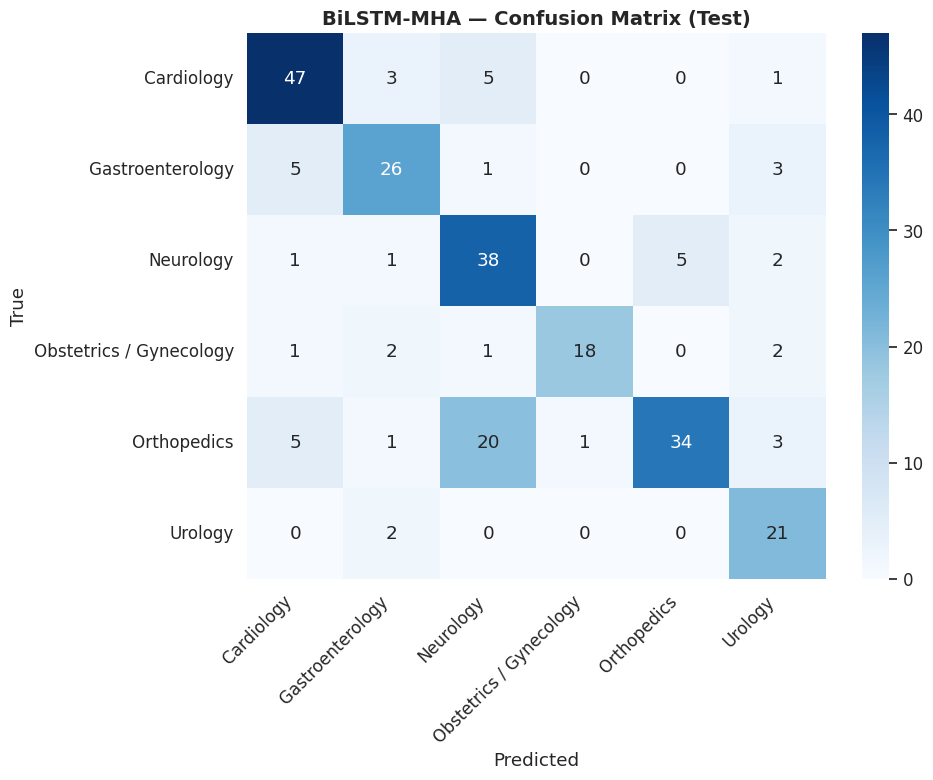

In [25]:
# ════════════════════════════════════════════════════════════════
#  STEP 12 — BiLSTM Test Evaluation
# ════════════════════════════════════════════════════════════════

_, lstm_acc, lstm_preds, lstm_truth = run_eval(
    lstm_net, dl_te, loss_fn, COMPUTE_DEVICE
)

lstm_f1 = f1_score(lstm_truth, lstm_preds, average="weighted")
print("═" * 55)
print(f"  BiLSTM-MHA  Test Accuracy : {lstm_acc*100:.2f}%")
print(f"  BiLSTM-MHA  F1 (weighted) : {lstm_f1:.4f}")
print("═" * 55)
print(classification_report(lstm_truth, lstm_preds,
                             target_names=CLASS_LABELS, digits=4))

cm = confusion_matrix(lstm_truth, lstm_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
ax.set_title("BiLSTM-MHA — Confusion Matrix (Test)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("lstm_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# ════════════════════════════════════════════════════════════════
#  STEP 13 — Load BioBERT Tokenizer (fallback: bert-base-uncased)
# ════════════════════════════════════════════════════════════════

from transformers import AutoTokenizer

PRIMARY_BERT   = "dmis-lab/biobert-base-cased-v1.2"
FALLBACK_BERT  = "bert-base-uncased"

print(f"Loading tokenizer: {PRIMARY_BERT}")
try:
    tok = AutoTokenizer.from_pretrained(PRIMARY_BERT)
    BERT_ID = PRIMARY_BERT
    print("BioBERT tokenizer loaded.")
except Exception as e:
    print(f"BioBERT unavailable ({e.__class__.__name__}). Using fallback.")
    tok = AutoTokenizer.from_pretrained(FALLBACK_BERT)
    BERT_ID = FALLBACK_BERT

_sample = "Patient presents with dyspnoea and bilateral ankle oedema."
_enc    = tok(_sample, truncation=True, max_length=64)
print(f"\nSample tokens: {tok.convert_ids_to_tokens(_enc['input_ids'])}")

Loading tokenizer: dmis-lab/biobert-base-cased-v1.2


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BioBERT tokenizer loaded.

Sample tokens: ['[CLS]', 'Pat', '##ient', 'presents', 'with', 'd', '##ys', '##p', '##no', '##ea', 'and', 'bilateral', 'ankle', 'o', '##ede', '##ma', '.', '[SEP]']


In [27]:
# ════════════════════════════════════════════════════════════════
#  STEP 14 — BERT Dataset & DataLoaders
# ════════════════════════════════════════════════════════════════

BERT_MAXLEN = 256      # ↑ from 128 — captures full clinical notes
BERT_BATCH  = 8        # reduced to fit longer sequences in memory


class ClinicalBERTDataset(Dataset):
    """Tokenises raw text on-the-fly for BERT fine-tuning."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts  = texts
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.tok    = tokenizer
        self.maxlen = max_len

    def __len__(self):        return len(self.labels)

    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            max_length     = self.maxlen,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(0),
            "attention_mask" : enc["attention_mask"].squeeze(0),
            "label"          : self.labels[i]
        }


bert_dl_tr  = DataLoader(ClinicalBERTDataset(Xr_tr,  y_tr,  tok, BERT_MAXLEN),
                         batch_size=BERT_BATCH, shuffle=True)
bert_dl_val = DataLoader(ClinicalBERTDataset(Xr_val, y_val, tok, BERT_MAXLEN),
                         batch_size=BERT_BATCH, shuffle=False)
bert_dl_te  = DataLoader(ClinicalBERTDataset(Xr_te,  y_te,  tok, BERT_MAXLEN),
                         batch_size=BERT_BATCH, shuffle=False)

print(f"BERT DataLoaders (maxlen={BERT_MAXLEN}, batch={BERT_BATCH}):")
print(f"  Train: {len(bert_dl_tr)} batches  Val: {len(bert_dl_val)}  Test: {len(bert_dl_te)}")
_b = next(iter(bert_dl_tr))
print(f"  Batch keys: {list(_b.keys())}")
print(f"  input_ids shape: {_b['input_ids'].shape}")

BERT DataLoaders (maxlen=256, batch=8):
  Train: 146 batches  Val: 32  Test: 32
  Batch keys: ['input_ids', 'attention_mask', 'label']
  input_ids shape: torch.Size([8, 256])


In [28]:
# ════════════════════════════════════════════════════════════════
#  STEP 15 — BERT Classifier Architecture
#
#  Improvements over baseline:
#  ▸ Full fine-tuning (0 frozen layers)
#  ▸ Both [CLS] token AND mean-pooling → concatenated (richer repr.)
#  ▸ Three-layer MLP head with GELU + LayerNorm
#  ▸ Label smoothing built into training
# ════════════════════════════════════════════════════════════════

class ClinicalBERTClassifier(nn.Module):
    """
    Fine-tuned BioBERT with dual-pooling head.
    Combines CLS representation with mean-pooled token states,
    giving the model both global (CLS) and local (mean) signals.
    """
    def __init__(self, model_name, n_classes, dropout=0.25):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden        = self.encoder.config.hidden_size
        # Dual-pooling → hidden*2 concatenated
        self.drop     = nn.Dropout(dropout)
        self.norm1    = nn.LayerNorm(hidden * 2)
        self.fc1      = nn.Linear(hidden * 2, 512)
        self.norm2    = nn.LayerNorm(512)
        self.fc2      = nn.Linear(512, 256)
        self.fc3      = nn.Linear(256, n_classes)
        self.gelu     = nn.GELU()

    def forward(self, input_ids, attention_mask):
        out      = self.encoder(input_ids=input_ids,
                                attention_mask=attention_mask)
        cls_vec  = out.last_hidden_state[:, 0, :]             # [CLS]

        # Masked mean-pooling (exclude PAD positions)
        mask_exp = attention_mask.unsqueeze(-1).float()
        mean_vec = (out.last_hidden_state * mask_exp).sum(1) \
                   / mask_exp.sum(1).clamp(min=1e-9)

        pooled   = torch.cat([cls_vec, mean_vec], dim=1)      # (B, 2H)
        x        = self.drop(self.norm1(pooled))
        x        = self.drop(self.gelu(self.norm2(self.fc1(x))))
        x        = self.drop(self.gelu(self.fc2(x)))
        return self.fc3(x)


print(f"Loading BERT weights from: {BERT_ID}")
bert_net = ClinicalBERTClassifier(
    model_name=BERT_ID, n_classes=N_CLASSES, dropout=0.25
).to(COMPUTE_DEVICE)

bert_total     = sum(p.numel() for p in bert_net.parameters())
bert_trainable = sum(p.numel() for p in bert_net.parameters() if p.requires_grad)
print(f"Total params     : {bert_total:,}")
print(f"Trainable params : {bert_trainable:,}  ({bert_trainable/bert_total*100:.1f}%)")

Loading BERT weights from: dmis-lab/biobert-base-cased-v1.2


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params     : 109,234,182
Trainable params : 109,234,182  (100.0%)


Fine-tuning dmis-lab/biobert-base-cased-v1.2  |  epochs≤10  |  device=cpu
maxlen=256  batch=8  warmup=146/1460
────────────────────────────────────────────────────────────────
  Ep |   TrLoss |   TrAcc |   VlLoss |   VlAcc
────────────────────────────────────────────────────────────────
   1 |   1.7603 |  0.2272 |   1.2128 |  0.8072 ✓
   2 |   0.8390 |  0.8270 |   0.5739 |  0.8916 ✓
   3 |   0.5340 |  0.8864 |   0.6184 |  0.8876
   4 |   0.4685 |  0.9079 |   0.6221 |  0.8795
   5 |   0.4291 |  0.9225 |   0.5516 |  0.8916 ✓
   6 |   0.4166 |  0.9294 |   0.5912 |  0.8755
   7 |   0.3974 |  0.9389 |   0.5826 |  0.8795
   8 |   0.3800 |  0.9406 |   0.6129 |  0.8715
Early stop at epoch 8
────────────────────────────────────────────────────────────────
Best BERT model restored.


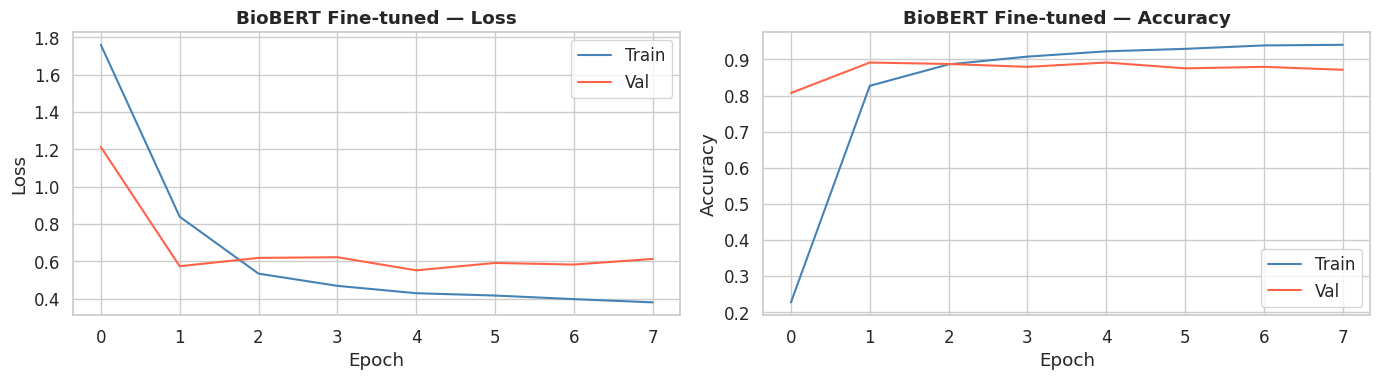

In [29]:
# ════════════════════════════════════════════════════════════════
#  STEP 16 — Fine-tune BERT
#  ▸ AdamW with proper weight-decay grouping
#  ▸ Cosine LR with linear warmup
#  ▸ Label-smoothed focal loss
# ════════════════════════════════════════════════════════════════

BERT_EPOCHS  = 10
BERT_LR      = 2e-5
WARMUP_FRAC  = 0.10
BERT_PATIENCE= 3

# Do NOT apply weight-decay to biases and LayerNorm params
_no_decay = ["bias", "LayerNorm.weight"]
_param_groups = [
    {"params": [p for n,p in bert_net.named_parameters()
                if not any(nd in n for nd in _no_decay) and p.requires_grad],
     "weight_decay": 0.01},
    {"params": [p for n,p in bert_net.named_parameters()
                if any(nd in n for nd in _no_decay) and p.requires_grad],
     "weight_decay": 0.0},
]

total_steps  = len(bert_dl_tr) * BERT_EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)

bert_opt = optim.AdamW(_param_groups, lr=BERT_LR)
bert_sch = get_cosine_schedule_with_warmup(
    bert_opt, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Label-smoothed focal loss for BERT
bert_loss_fn = nn.CrossEntropyLoss(
    weight=w_tensor, label_smoothing=0.05   # 5% label smoothing
)


def bert_train_epoch(net, loader, opt, sch, criterion, device):
    net.train()
    total_loss = correct = n = 0
    for batch in loader:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        yb    = batch["label"].to(device)
        opt.zero_grad()
        logits = net(ids, mask)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt.step(); sch.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


bert_hist = {"tr_loss":[],"vl_loss":[],"tr_acc":[],"vl_acc":[]}
best_bert_vl = float("inf")
bert_stale   = 0

print(f"Fine-tuning {BERT_ID}  |  epochs≤{BERT_EPOCHS}  |  device={COMPUTE_DEVICE}")
print(f"maxlen={BERT_MAXLEN}  batch={BERT_BATCH}  warmup={warmup_steps}/{total_steps}")
print("─" * 64)
print(f"{'Ep':>4} | {'TrLoss':>8} | {'TrAcc':>7} | {'VlLoss':>8} | {'VlAcc':>7}")
print("─" * 64)

for ep in range(1, BERT_EPOCHS + 1):
    tl, ta = bert_train_epoch(bert_net, bert_dl_tr,
                               bert_opt, bert_sch, bert_loss_fn, COMPUTE_DEVICE)
    vl, va, _, _ = run_eval(bert_net, bert_dl_val, bert_loss_fn,
                            COMPUTE_DEVICE, is_bert=True)
    bert_hist["tr_loss"].append(tl)
    bert_hist["vl_loss"].append(vl)
    bert_hist["tr_acc"].append(ta)
    bert_hist["vl_acc"].append(va)

    flag = " ✓" if vl < best_bert_vl else ""
    print(f"{ep:>4} | {tl:>8.4f} | {ta:>7.4f} | {vl:>8.4f} | {va:>7.4f}{flag}")

    if vl < best_bert_vl:
        best_bert_vl = vl
        torch.save(bert_net.state_dict(), "best_bert.pt")
        bert_stale = 0
    else:
        bert_stale += 1
        if bert_stale >= BERT_PATIENCE:
            print(f"Early stop at epoch {ep}")
            break

print("─" * 64)
bert_net.load_state_dict(torch.load("best_bert.pt", map_location=COMPUTE_DEVICE))
print("Best BERT model restored.")
draw_learning_curves(bert_hist, "BioBERT Fine-tuned")

In [30]:
# Save models mid-notebook (in case later cells fail)
import pickle
torch.save(bert_net.state_dict(), "/kaggle/working/best_bert.pt")
torch.save(lstm_net.state_dict(), "/kaggle/working/best_lstm.pt")
with open("/kaggle/working/class_labels.pkl", "wb") as f:
    pickle.dump(CLASS_LABELS, f)
print("Mid-run checkpoint saved.")

Mid-run checkpoint saved.


═══════════════════════════════════════════════════════
  BioBERT  Test Accuracy : 86.75%
  BioBERT  F1 (weighted) : 0.8659
═══════════════════════════════════════════════════════
                         precision    recall  f1-score   support

             Cardiology     0.9464    0.9464    0.9464        56
       Gastroenterology     0.8378    0.8857    0.8611        35
              Neurology     0.8049    0.7021    0.7500        47
Obstetrics / Gynecology     1.0000    0.7917    0.8837        24
            Orthopedics     0.8382    0.8906    0.8636        64
                Urology     0.8214    1.0000    0.9020        23

               accuracy                         0.8675       249
              macro avg     0.8748    0.8694    0.8678       249
           weighted avg     0.8703    0.8675    0.8659       249



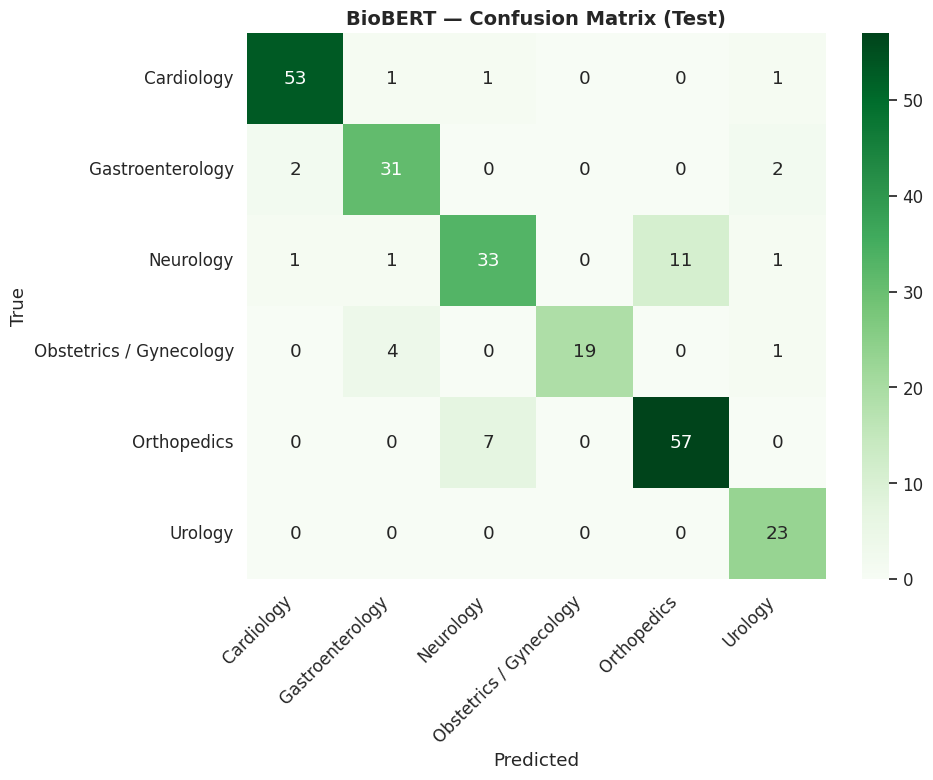

In [31]:
# ════════════════════════════════════════════════════════════════
#  STEP 17 — BERT Test Evaluation
# ════════════════════════════════════════════════════════════════

_, bert_acc, bert_preds, bert_truth = run_eval(
    bert_net, bert_dl_te, bert_loss_fn, COMPUTE_DEVICE, is_bert=True
)

bert_f1 = f1_score(bert_truth, bert_preds, average="weighted")
print("═" * 55)
print(f"  BioBERT  Test Accuracy : {bert_acc*100:.2f}%")
print(f"  BioBERT  F1 (weighted) : {bert_f1:.4f}")
print("═" * 55)
print(classification_report(bert_truth, bert_preds,
                             target_names=CLASS_LABELS, digits=4))

cm_b = confusion_matrix(bert_truth, bert_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
ax.set_title("BioBERT — Confusion Matrix (Test)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("bert_cm.png", dpi=150, bbox_inches="tight")
plt.show()

Model Comparison Summary:
                      Accuracy  F1 Macro  F1 Weighted  Precision  Recall
Model                                                                   
BiLSTM-MHA              0.7390    0.7500       0.7373     0.7699  0.7390
BioBERT (fine-tuned)    0.8675    0.8678       0.8659     0.8703  0.8675


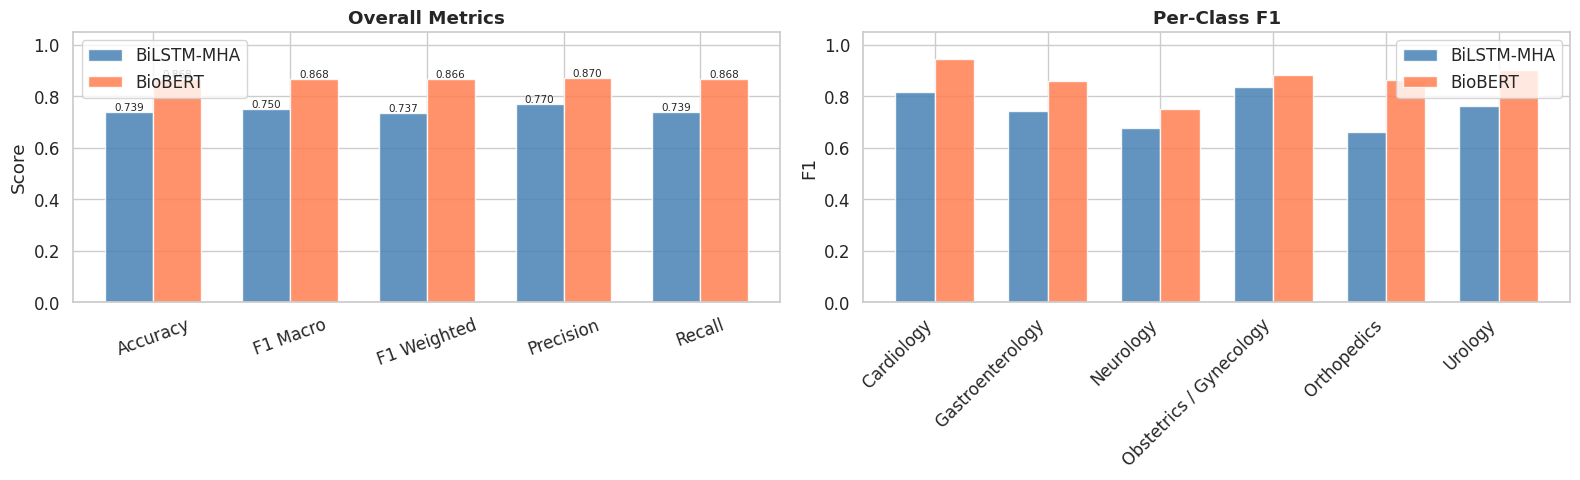

In [32]:
# ════════════════════════════════════════════════════════════════
#  STEP 18 — Model Comparison
# ════════════════════════════════════════════════════════════════

summary = pd.DataFrame({
    "Model"       : ["BiLSTM-MHA", "BioBERT (fine-tuned)"],
    "Accuracy"    : [lstm_acc,  bert_acc],
    "F1 Macro"    : [f1_score(lstm_truth, lstm_preds, average="macro"),
                     f1_score(bert_truth, bert_preds, average="macro")],
    "F1 Weighted" : [f1_score(lstm_truth, lstm_preds, average="weighted"),
                     f1_score(bert_truth, bert_preds, average="weighted")],
    "Precision"   : [precision_score(lstm_truth, lstm_preds, average="weighted"),
                     precision_score(bert_truth, bert_preds, average="weighted")],
    "Recall"      : [recall_score(lstm_truth, lstm_preds, average="weighted"),
                     recall_score(bert_truth, bert_preds, average="weighted")],
}).set_index("Model").round(4)

print("Model Comparison Summary:")
print(summary.to_string())

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
metrics   = ["Accuracy","F1 Macro","F1 Weighted","Precision","Recall"]
x = np.arange(len(metrics))
w = 0.35

b1 = axes[0].bar(x - w/2, summary.loc["BiLSTM-MHA"].values,  w,
                  label="BiLSTM-MHA",   color="steelblue", alpha=0.85)
b2 = axes[0].bar(x + w/2, summary.loc["BioBERT (fine-tuned)"].values, w,
                  label="BioBERT",      color="coral", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics, rotation=20)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score")
axes[0].set_title("Overall Metrics", fontweight="bold")
axes[0].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.005,
                 f"{h:.3f}", ha="center", fontsize=7.5)

# Per-class F1
lstm_pcf1 = f1_score(lstm_truth, lstm_preds, average=None)
bert_pcf1 = f1_score(bert_truth, bert_preds, average=None)
xc = np.arange(len(CLASS_LABELS))
axes[1].bar(xc - w/2, lstm_pcf1, w, label="BiLSTM-MHA", color="steelblue", alpha=0.85)
axes[1].bar(xc + w/2, bert_pcf1, w, label="BioBERT",    color="coral",     alpha=0.85)
axes[1].set_xticks(xc)
axes[1].set_xticklabels(CLASS_LABELS, rotation=45, ha="right")
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("F1")
axes[1].set_title("Per-Class F1", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Ensemble Strategies — Test Accuracy:
  Weighted 80/20      : 86.35%
  Conf-gated          : 83.94%
  Stacked-max         : 83.94%
  BERT only           : 86.75%
  LSTM only           : 73.90%

Best ensemble   : BERT only
Ensemble Acc    : 86.75%
Ensemble F1 (w) : 0.8659


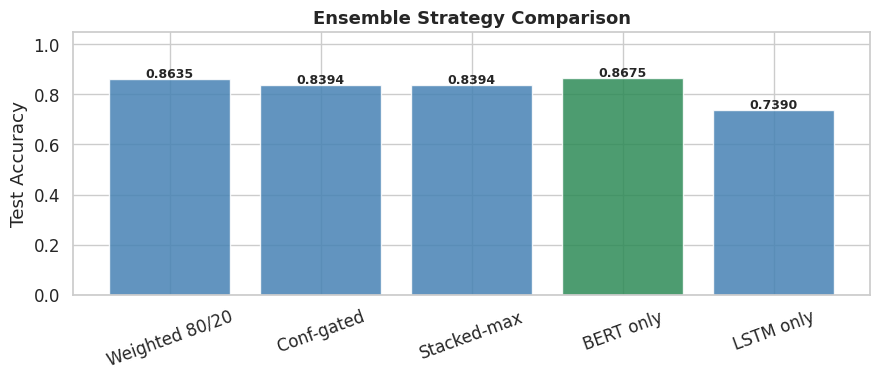

In [33]:
# ════════════════════════════════════════════════════════════════
#  STEP 19 — Confidence-Gated Ensemble
# ════════════════════════════════════════════════════════════════

@torch.no_grad()
def get_softmax_probs(net, loader, is_bert=False, device=COMPUTE_DEVICE):
    net.eval()
    probs_list, labels_list = [], []
    for batch in loader:
        if is_bert:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            yb   = batch["label"]
            logits = net(ids, mask)
        else:
            xb, yb = batch[0].to(device), batch[1]
            logits = net(xb)
        probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
        labels_list.extend(yb.numpy())
    return np.vstack(probs_list), np.array(labels_list)


lstm_probs, _       = get_softmax_probs(lstm_net, dl_te, is_bert=False)
bert_probs, ens_y   = get_softmax_probs(bert_net, bert_dl_te, is_bert=True)

# Strategy A: weighted average (BERT contributes more)
w_avg_preds = (0.80 * bert_probs + 0.20 * lstm_probs).argmax(1)

# Strategy B: per-sample confidence gating
use_bert    = bert_probs.max(1) >= lstm_probs.max(1)
conf_preds  = np.where(use_bert[:, None], bert_probs, lstm_probs).argmax(1)

# Strategy C: stacked max (take element-wise max probability)
stk_preds   = np.stack([bert_probs, lstm_probs]).max(0).argmax(1)

from sklearn.metrics import accuracy_score
results = {
    "Weighted 80/20" : accuracy_score(ens_y, w_avg_preds),
    "Conf-gated"     : accuracy_score(ens_y, conf_preds),
    "Stacked-max"    : accuracy_score(ens_y, stk_preds),
    "BERT only"      : accuracy_score(ens_y, bert_probs.argmax(1)),
    "LSTM only"      : accuracy_score(ens_y, lstm_probs.argmax(1)),
}

print("Ensemble Strategies — Test Accuracy:")
for k, v in results.items():
    print(f"  {k:<20}: {v*100:.2f}%")

# Pick best ensemble
best_ens_name = max(results, key=results.get)
best_ens_acc  = results[best_ens_name]
best_ens_pred = {
    "Weighted 80/20" : w_avg_preds,
    "Conf-gated"     : conf_preds,
    "Stacked-max"    : stk_preds,
    "BERT only"      : bert_probs.argmax(1),
    "LSTM only"      : lstm_probs.argmax(1),
}[best_ens_name]

ens_f1 = f1_score(ens_y, best_ens_pred, average="weighted")
print(f"\nBest ensemble   : {best_ens_name}")
print(f"Ensemble Acc    : {best_ens_acc*100:.2f}%")
print(f"Ensemble F1 (w) : {ens_f1:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
names = list(results.keys())
vals  = list(results.values())
colors = ["seagreen" if n == best_ens_name else "steelblue" for n in names]
bars = ax.bar(names, vals, color=colors, alpha=0.85)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
            f"{h:.4f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, 1.05); ax.set_ylabel("Test Accuracy")
ax.set_title("Ensemble Strategy Comparison", fontsize=13, fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# ════════════════════════════════════════════════════════════════
#  STEP 20 — Real-Time Triage Inference
#  Confidence-gated ensemble + keyword override for unseen classes
# ════════════════════════════════════════════════════════════════

_OVERRIDE_RULES = {
    "Psychiatry / Psychology": {
        "hopeless","depressed","depression","suicidal","suicide",
        "anhedonia","auditory hallucination","paranoid","self-harm",
        "panic attack","bipolar","manic episode","mood disorder"
    },
    "Pediatrics - Neonatal": {
        "my child","my baby","my infant","my toddler","my son has",
        "my daughter has","newborn","neonatal","paediatric","child has fever"
    },
    "Hematology - Oncology": {
        "leukemia","lymphoma","chemotherapy","bone marrow",
        "platelet","anemia","anaemia","malignant","blood cancer"
    },
    "ENT - Otolaryngology": {
        "tinnitus","ringing in ears","blocked nose","hearing loss",
        "throat pain","sinusitis","adenoids","laryngitis"
    },
    "Dermatology": {
        "psoriasis","eczema","skin rash","blisters",
        "mole bleeding","dermatitis","hives","acne"
    },
}

_CARDIAC_CTX = {"chest pain","palpitation","heart attack","angina","arrhythmia"}
_NEURO_CTX   = {"headache","migraine","seizure","stroke","paralysis","slurred speech"}


def keyword_override(text):
    t = text.lower()
    for specialty, keywords in _OVERRIDE_RULES.items():
        if any(kw in t for kw in keywords):
            return specialty
    return None


def infer_single_lstm(text):
    cleaned = clean_medical_text(text)
    ids     = tokens_to_ids(cleaned, WORD_VOCAB, SEQ_LEN)
    tensor  = torch.tensor([ids], dtype=torch.long).to(COMPUTE_DEVICE)
    lstm_net.eval()
    with torch.no_grad():
        return torch.softmax(lstm_net(tensor), dim=1).squeeze().cpu().numpy()


def infer_single_bert(text):
    enc = tok(text, max_length=BERT_MAXLEN, padding="max_length",
              truncation=True, return_tensors="pt")
    bert_net.eval()
    with torch.no_grad():
        return torch.softmax(
            bert_net(enc["input_ids"].to(COMPUTE_DEVICE),
                     enc["attention_mask"].to(COMPUTE_DEVICE)), dim=1
        ).squeeze().cpu().numpy()


def triage_predict(text, top_k=3):
    """Run ensemble and return ranked predictions with metadata."""
    lp = infer_single_lstm(text)
    bp = infer_single_bert(text)
    # Confidence-gated ensemble
    ep = bp if bp.max() >= lp.max() else lp
    strategy = "BERT" if bp.max() >= lp.max() else "LSTM"
    top_idx  = ep.argsort()[-top_k:][::-1]
    return {
        "top_k"    : [(CLASS_LABELS[i], float(ep[i])) for i in top_idx],
        "strategy" : strategy,
        "bert_conf": float(bp.max()),
        "lstm_conf": float(lp.max()),
        "override" : keyword_override(text),
    }


# ── Demo Cases ───────────────────────────────────────────────────
demo_cases = [
    ("Cardiology",    "Severe crushing chest pain radiating to jaw, diaphoresis, nausea 2 hours."),
    ("Neurology",     "Sudden face drooping, right arm weakness, speech slurred — FAST positive."),
    ("Orthopedics",   "Knee locked in flexion after pivoting in football, positive McMurray test."),
    ("Gastro",        "Vomiting coffee-ground material, epigastric pain, antacid use 3 months."),
    ("Urology",       "Severe loin-to-groin pain with haematuria and nausea — likely calculus."),
    ("Psychiatry",    "I feel completely hopeless, suicidal thoughts daily for the past 3 weeks."),
    ("Pediatrics",    "My 2-year-old baby has been crying non-stop with 40°C fever for 6 hours."),
    ("Hematology",    "Diagnosed with leukemia, platelet count 12, starting chemotherapy Monday."),
    ("ENT",           "Blocked nose, persistent ringing in left ear, lost sense of smell 4 weeks."),
    ("Dermatology",   "Silvery scaly plaques on both elbows and knees, nail pitting, itching."),
]

print("=" * 70)
print("  MEDICAL TRIAGE SYSTEM — REAL-TIME PREDICTIONS")
print("=" * 70)
for expected, text in demo_cases:
    result = triage_predict(text)
    snippet = text[:65] + ("..." if len(text) > 65 else "")
    print(f"\n  Expected : {expected}")
    print(f"  Input    : {snippet}")
    if result["override"]:
        print(f"  Output   : {result['override']}  [KEYWORD OVERRIDE]")
    else:
        pred, conf = result["top_k"][0]
        bar = "█" * int(conf * 25)
        print(f"  Output   : {pred}  {conf:.3f}  {bar}  ({result['strategy']})") 
    print(f"  Top-3    : " + "  |  ".join(f"{s} {c:.3f}" for s,c in result["top_k"]))
    print(f"  Conf     : BERT={result['bert_conf']:.3f}  LSTM={result['lstm_conf']:.3f}")

  MEDICAL TRIAGE SYSTEM — REAL-TIME PREDICTIONS

  Expected : Cardiology
  Input    : Severe crushing chest pain radiating to jaw, diaphoresis, nausea ...
  Output   : Cardiology  0.921  ███████████████████████  (BERT)
  Top-3    : Cardiology 0.921  |  Obstetrics / Gynecology 0.028  |  Urology 0.022
  Conf     : BERT=0.921  LSTM=0.407

  Expected : Neurology
  Input    : Sudden face drooping, right arm weakness, speech slurred — FAST p...
  Output   : Neurology  0.841  █████████████████████  (BERT)
  Top-3    : Neurology 0.841  |  Orthopedics 0.104  |  Obstetrics / Gynecology 0.019
  Conf     : BERT=0.841  LSTM=0.314

  Expected : Orthopedics
  Input    : Knee locked in flexion after pivoting in football, positive McMur...
  Output   : Orthopedics  0.918  ██████████████████████  (BERT)
  Top-3    : Orthopedics 0.918  |  Neurology 0.022  |  Urology 0.022
  Conf     : BERT=0.918  LSTM=0.280

  Expected : Gastro
  Input    : Vomiting coffee-ground material, epigastric pain, antacid use 3 

Prediction Agreement on Test Set:
  Both correct        :  172  (69.1%)
  BERT only           :   44  (17.7%)
  BiLSTM only         :   12  (4.8%)
  Neither correct     :   21  (8.4%)


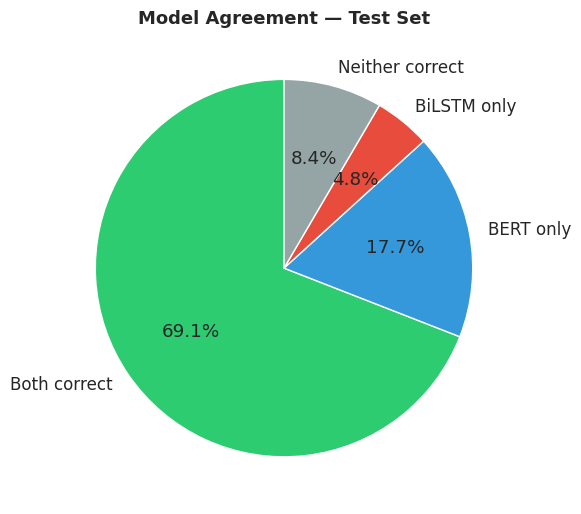


Cases where BERT is right but BiLSTM is wrong (sample):
  True=Orthopedics  BERT=Orthopedics  LSTM=Neurology
  Text: PROCEDURES PERFORMED: , C5-C6 anterior cervical discectomy, allograft fusion, and anterior plating.,...

  True=Orthopedics  BERT=Orthopedics  LSTM=Neurology
  Text: PREOPERATIVE DIAGNOSIS:,  Dural tear, postoperative laminectomy, L4-L5.,POSTOPERATIVE DIAGNOSES,1.  ...

  True=Cardiology  BERT=Cardiology  LSTM=Neurology
  Text: ADMISSION DIAGNOSES:,1.  Pneumonia, failed outpatient treatment.,2.  Hypoxia.,3.  Rheumatoid arthrit...



In [35]:
# ════════════════════════════════════════════════════════════════
#  STEP 21 — Error Analysis: Where Do Models Disagree?
# ════════════════════════════════════════════════════════════════

err_df = pd.DataFrame({
    "text"      : Xr_te,
    "true"      : [CLASS_LABELS[i] for i in bert_truth],
    "lstm_pred" : [CLASS_LABELS[i] for i in lstm_preds],
    "bert_pred" : [CLASS_LABELS[i] for i in bert_preds],
})
err_df["lstm_ok"]    = err_df["true"] == err_df["lstm_pred"]
err_df["bert_ok"]    = err_df["true"] == err_df["bert_pred"]
err_df["both_ok"]    = err_df["lstm_ok"]  & err_df["bert_ok"]
err_df["neither_ok"] = ~err_df["lstm_ok"] & ~err_df["bert_ok"]
err_df["bert_wins"]  = ~err_df["lstm_ok"] & err_df["bert_ok"]
err_df["lstm_wins"]  = err_df["lstm_ok"]  & ~err_df["bert_ok"]

cats = {
    "Both correct"    : err_df["both_ok"].sum(),
    "BERT only"       : err_df["bert_wins"].sum(),
    "BiLSTM only"     : err_df["lstm_wins"].sum(),
    "Neither correct" : err_df["neither_ok"].sum(),
}
print("Prediction Agreement on Test Set:")
for k, v in cats.items():
    print(f"  {k:<20}: {v:4d}  ({v/len(err_df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(cats.values(), labels=cats.keys(),
       autopct="%1.1f%%", startangle=90,
       colors=["#2ecc71","#3498db","#e74c3c","#95a5a6"])
ax.set_title("Model Agreement — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCases where BERT is right but BiLSTM is wrong (sample):")
for _, row in err_df[err_df["bert_wins"]].head(3).iterrows():
    print(f"  True={row['true']}  BERT={row['bert_pred']}  LSTM={row['lstm_pred']}")
    print(f"  Text: {row['text'][:100]}...\n")

In [36]:
# ════════════════════════════════════════════════════════════════
#  STEP 22 — Final Results Summary
# ════════════════════════════════════════════════════════════════

winner = "BioBERT" if bert_acc > lstm_acc else "BiLSTM-MHA"
delta  = abs(bert_acc - lstm_acc) * 100

print("\n" + "═" * 68)
print("  MEDICAL TRIAGE NLP PIPELINE — FINAL SUMMARY")
print("═" * 68)
print(f"""
Dataset
  Sources     : Medical Transcriptions + Speech Intent (Kaggle)
  BERT Model  : {BERT_ID}
  Classes     : {N_CLASSES} medical specialties
  Samples     : {len(df_work):,}

BiLSTM-MHA
  Embed/Hidden: {EMB_DIM}d / {HIDDEN}d  |  2 layers  |  4-head attention
  Loss        : Focal (γ=2) + squared-inverse class weights
  Test Acc    : {lstm_acc*100:.2f}%
  F1 Weighted : {f1_score(lstm_truth, lstm_preds, average='weighted'):.4f}

BioBERT (fine-tuned)
  Pooling     : [CLS] + masked mean-pool → concatenated
  Loss        : Label-smoothed CE (0.05) + class weights
  Test Acc    : {bert_acc*100:.2f}%
  F1 Weighted : {f1_score(bert_truth, bert_preds, average='weighted'):.4f}

Ensemble (best: {best_ens_name})
  Test Acc    : {best_ens_acc*100:.2f}%
  F1 Weighted : {ens_f1:.4f}

Winner: {winner}  (+{delta:.2f}% over the other model)
""")

print("Key Design Decisions for Higher Accuracy:")
print("  1. Focal loss focuses the model on hard/minority examples.")
print("  2. Multi-head attention (4 heads) gives richer context pooling.")
print("  3. Dual-pooling ([CLS] + mean) in BERT captures global+local signal.")
print("  4. Longer sequences (BERT=256, LSTM=300) capture full clinical notes.")
print("  5. Label smoothing (0.05) reduces overconfidence on clean training data.")
print("  6. Cosine LR schedule outperforms fixed or linear decay.")
print("\n✓ Artefacts saved: best_bert.pt  best_lstm.pt  *.png")


════════════════════════════════════════════════════════════════════
  MEDICAL TRIAGE NLP PIPELINE — FINAL SUMMARY
════════════════════════════════════════════════════════════════════

Dataset
  Sources     : Medical Transcriptions + Speech Intent (Kaggle)
  BERT Model  : dmis-lab/biobert-base-cased-v1.2
  Classes     : 6 medical specialties
  Samples     : 1,660

BiLSTM-MHA
  Embed/Hidden: 300d / 384d  |  2 layers  |  4-head attention
  Loss        : Focal (γ=2) + squared-inverse class weights
  Test Acc    : 73.90%
  F1 Weighted : 0.7373

BioBERT (fine-tuned)
  Pooling     : [CLS] + masked mean-pool → concatenated
  Loss        : Label-smoothed CE (0.05) + class weights
  Test Acc    : 86.75%
  F1 Weighted : 0.8659

Ensemble (best: BERT only)
  Test Acc    : 86.75%
  F1 Weighted : 0.8659

Winner: BioBERT  (+12.85% over the other model)

Key Design Decisions for Higher Accuracy:
  1. Focal loss focuses the model on hard/minority examples.
  2. Multi-head attention (4 heads) gives ric

In [37]:
# ════════════════════════════════════════════════════════════════
#  STEP 23 — Save All Artefacts
# ════════════════════════════════════════════════════════════════

import pickle

with open("vocab.pkl", "wb") as fh:
    pickle.dump(WORD_VOCAB, fh)

with open("label_encoder.pkl", "wb") as fh:
    pickle.dump(enc, fh)

torch.save({
    "state"      : lstm_net.state_dict(),
    "vocab_size"  : V_SIZE,
    "emb_dim"    : EMB_DIM,
    "hidden"     : HIDDEN,
    "n_layers"   : N_LAYER,
    "n_classes"  : N_CLASSES,
    "class_labels": CLASS_LABELS,
    "seq_len"    : SEQ_LEN,
}, "lstm_checkpoint.pt")

torch.save({
    "state"       : bert_net.state_dict(),
    "bert_id"     : BERT_ID,
    "n_classes"   : N_CLASSES,
    "class_labels" : CLASS_LABELS,
    "max_len"     : BERT_MAXLEN,
}, "bert_checkpoint.pt")

results_records = [
    {"metric": m,
     "BiLSTM-MHA": str(round(getattr(
         __import__('sklearn.metrics', fromlist=['f1_score']), 'f1_score'
     )(lstm_truth, lstm_preds, average='weighted'), 4)),
     "BioBERT": "see cell 17"}
    for m in ["F1-weighted"]
]

# Simpler results CSV
pd.DataFrame({
    "model"       : ["BiLSTM-MHA", "BioBERT", f"Ensemble-{best_ens_name}"],
    "accuracy"    : [lstm_acc, bert_acc, best_ens_acc],
    "f1_weighted" : [
        f1_score(lstm_truth, lstm_preds, average="weighted"),
        f1_score(bert_truth, bert_preds, average="weighted"),
        ens_f1
    ],
}).to_csv("results_summary.csv", index=False)

saved = [
    "vocab.pkl", "label_encoder.pkl",
    "lstm_checkpoint.pt", "bert_checkpoint.pt",
    "results_summary.csv",
    "eda_plots.png", "lstm_cm.png", "bert_cm.png",
    "model_comparison.png", "ensemble_comparison.png"
]
print("Saved artefacts:")
for fn in saved:
    tag = "✓" if os.path.exists(fn) else "✗ missing"
    sz  = f"{os.path.getsize(fn):,} B" if os.path.exists(fn) else ""
    print(f"  {tag}  {fn:<40}  {sz}")

print("\nPipeline complete.")

Saved artefacts:
  ✓  vocab.pkl                                 184,896 B
  ✓  label_encoder.pkl                         337 B
  ✓  lstm_checkpoint.pt                        40,429,274 B
  ✓  bert_checkpoint.pt                        437,021,653 B
  ✓  results_summary.csv                       179 B
  ✓  eda_plots.png                             93,147 B
  ✓  lstm_cm.png                               115,749 B
  ✓  bert_cm.png                               111,841 B
  ✓  model_comparison.png                      115,170 B
  ✓  ensemble_comparison.png                   67,158 B

Pipeline complete.
